In [1]:
from sklearn import svm
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 선형 분리 가능한 데이터 생성
X, y = make_classification(
    n_samples=100,           # 100개의 샘플
    n_features=2,            # 2차원 (시각화용)
    n_redundant=0,           # 불필요한 특징 없음
    n_informative=2,         # 모든 특징이 유용
    n_clusters_per_class=1,  # 각 클래스당 1개 클러스터
    class_sep=2.0,          # 클래스 간 큰 간격
    random_state=42          # 재현성을 위한 시드
)

In [3]:
X.shape

(100, 2)

In [4]:
y.shape

(100,)

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

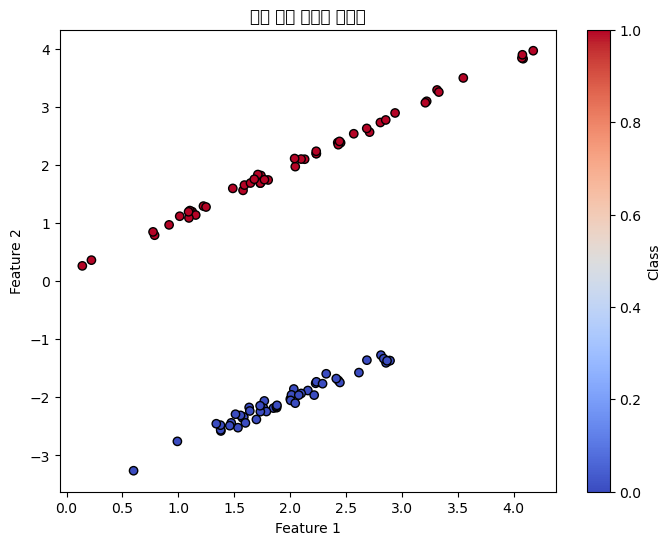

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap='coolwarm', edgecolors='black')
# 슬라이싱 기법 ㅣ X값에 1번재 컬럼 X값에 2번째 컬럼
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('선형 분리 가능한 데이터')
plt.colorbar(label='Class')
plt.show()

In [9]:
# Linear Kernel SVM 생성 및 학습
linear_svm = svm.SVC(
    kernel='linear',  # Linear Kernel 사용
    C=1.0            # 기본 C 값
)

In [10]:
# 모델 학습
linear_svm.fit(X, y)

SVC(kernel='linear')

In [11]:
# 학습 결과 확인
print(f"Support Vectors 개수: {len(linear_svm.support_)}")
print(f"Support Vectors 인덱스: {linear_svm.support_[:5]}...")
print(f"Training Accuracy: {linear_svm.score(X, y):.3f}")

Support Vectors 개수: 3
Support Vectors 인덱스: [ 8 72 82]...
Training Accuracy: 1.000


In [12]:
linear_svm.support_vectors_

array([[ 2.32272135, -1.59340317],
       [ 0.78801347,  0.79334842],
       [ 0.14147759,  0.26526486]])

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


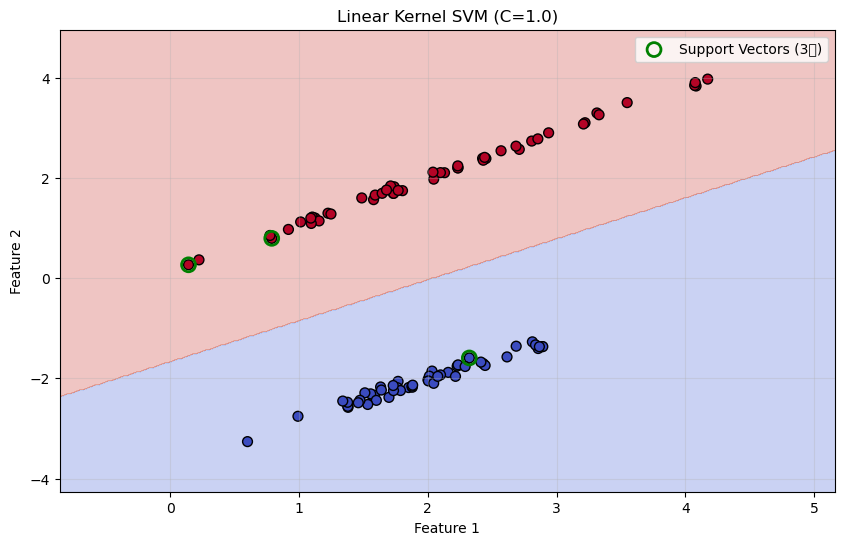

In [42]:
def plot_decision_boundary(clf, X, y, title):
    """SVM 결정 경계를 시각화하는 함수"""
    
    # 메쉬 그리드 생성을 위한 범위 설정
    h = .02  # 메쉬 간격
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # 메쉬 그리드 생성
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    # 각 메쉬 포인트에서 예측
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 시각화
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # 데이터 포인트
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
               edgecolors='black', s=50)
    
    # Support Vectors 강조
    plt.scatter(clf.support_vectors_[:, 0], 
               clf.support_vectors_[:, 1], 
               s=100, facecolors='none', 
               edgecolors='green', linewidths=2,
               label=f'Support Vectors ({len(clf.support_)}개)')
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 시각화 실행
plot_decision_boundary(clf_linear, X, y, 'Linear Kernel SVM (C=1.0)')

In [16]:
# XOR 패턴 데이터 생성
np.random.seed(42) # 이거 안해도 자동으로 42됨

# 무작위 2D 포인트 생성
X_nonlinear = np.random.randn(200, 2)

In [17]:
X_nonlinear.shape

(200, 2)

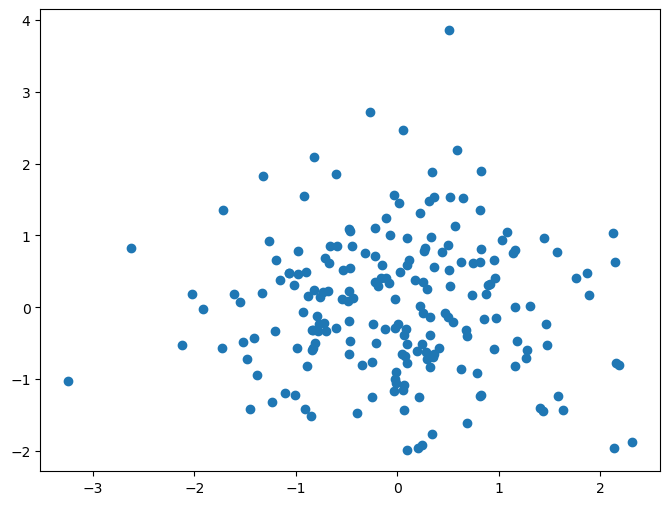

In [18]:
# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x = X_nonlinear[:, 0], y = X_nonlinear[:, 1])

In [19]:
# XOR 패턴으로 라벨 생성
# x>0 AND y>0 이거나 x<0 AND y<0 이면 Class 0
# 그 외는 Class 1
y_nonlinear = np.logical_xor(
    X_nonlinear[:, 0] > 0, 
    X_nonlinear[:, 1] > 0
).astype(int)  #결과값 True False를 astype해서 0 1 로 나오게함

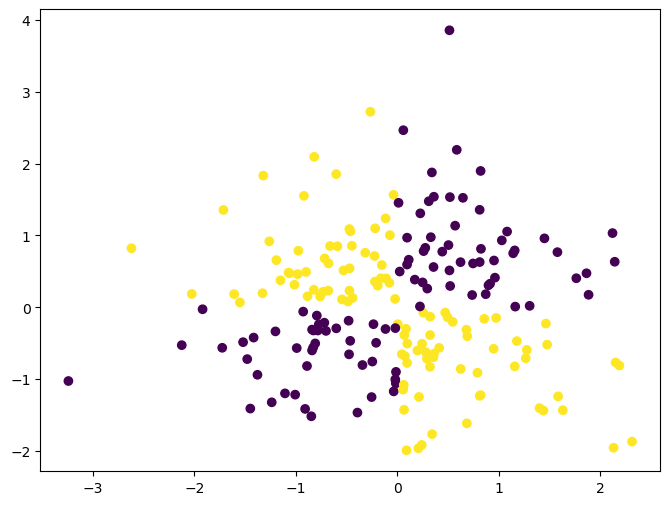

In [20]:
# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x = X_nonlinear[:, 0], y = X_nonlinear[:, 1],c=y_nonlinear)

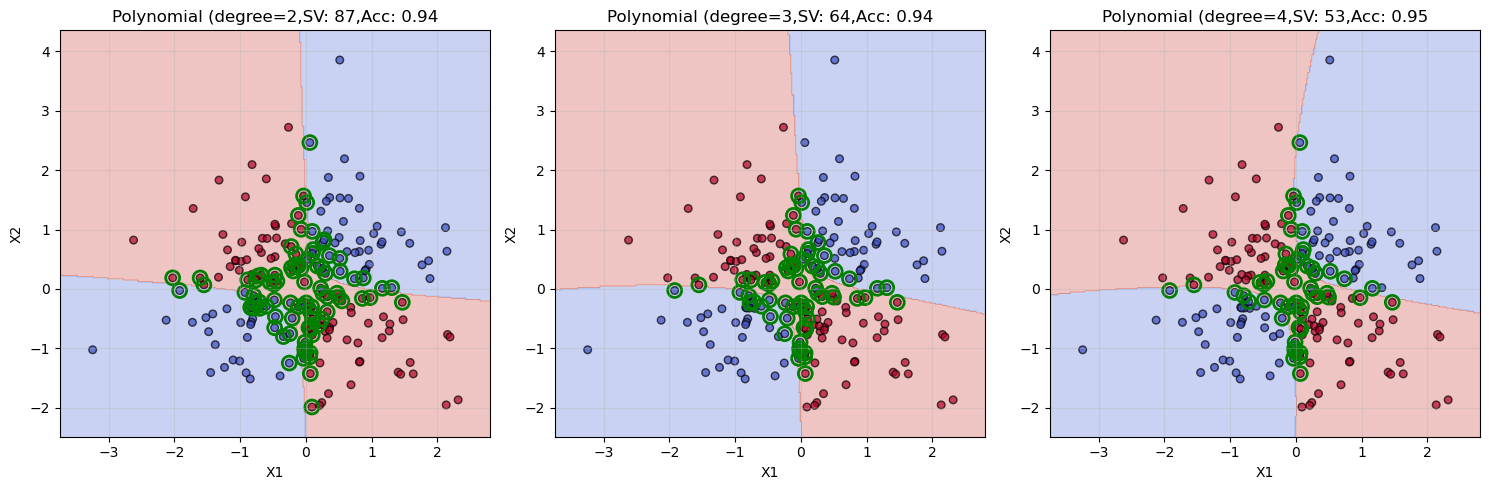

In [23]:
# 다양한 degree로 Polynomial Kernel SVM 학습
degrees = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, degree in enumerate(degrees):
    ax = axes[idx]
    
    # Polynomial Kernel SVM 생성 및 학습
    clf_poly = svm.SVC(
        kernel='poly', 
        degree=degree,      # 다항식 차수
        gamma='auto',       # 자동 gamma 설정
        C=1.0,             # 기본 C 값
        coef0=1            # 상수항
    )
    clf_poly.fit(X_nonlinear, y_nonlinear)
    
    # 결정 경계 그리기
    h = .02
    x_min = X_nonlinear[:, 0].min() - 0.5
    x_max = X_nonlinear[:, 0].max() + 0.5
    y_min = X_nonlinear[:, 1].min() - 0.5
    y_max = X_nonlinear[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    Z = clf_poly.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 시각화
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], 
              c=y_nonlinear, cmap='coolwarm', 
              s=30, edgecolors='black', alpha=0.7)
    
    # Support Vectors 표시
    ax.scatter(clf_poly.support_vectors_[:, 0],
              clf_poly.support_vectors_[:, 1],
              s=100, facecolors='none', 
              edgecolors='green', linewidths=2)
    
    # 제목과 정보
    ax.set_title(f'Polynomial (degree={degree},'
                f'SV: {len(clf_poly.support_)},'
                f'Acc: {clf_poly.score(X_nonlinear, y_nonlinear):.2f}')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

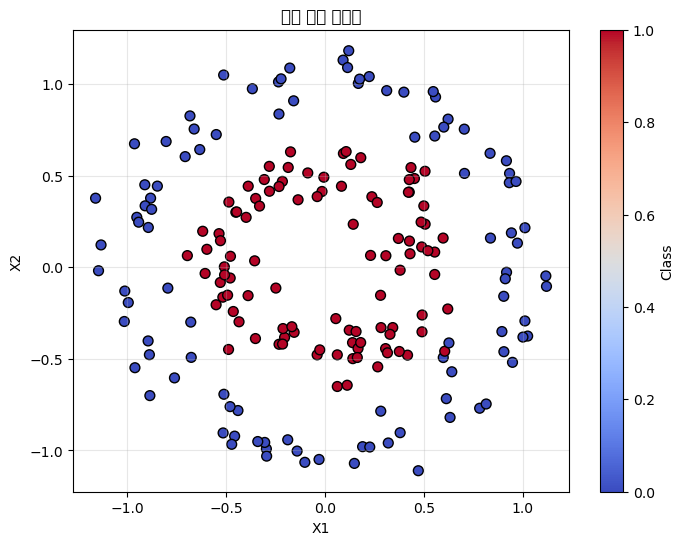

원형 패턴은 선형으로 절대 분리 불가능!
RBF Kernel이 이런 패턴에 완벽함


In [26]:
# 원형 패턴 데이터 생성
from sklearn.datasets import make_circles
import seaborn as sns

X_circles, y_circles = make_circles(
    n_samples=200,    # 샘플 수
    factor=0.5,       # 내부/외부 원의 크기 비율
    noise=0.1,        # 노이즈 레벨
    random_state=42
)

# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_circles[:, 0], X_circles[:, 1], 
           c=y_circles, cmap='coolwarm', 
           edgecolors='black', s=50)
plt.title('원형 패턴 데이터')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(label='Class')
plt.grid(True, alpha=0.3)
plt.show()

print("원형 패턴은 선형으로 절대 분리 불가능!")
print("RBF Kernel이 이런 패턴에 완벽함")

<Axes: >

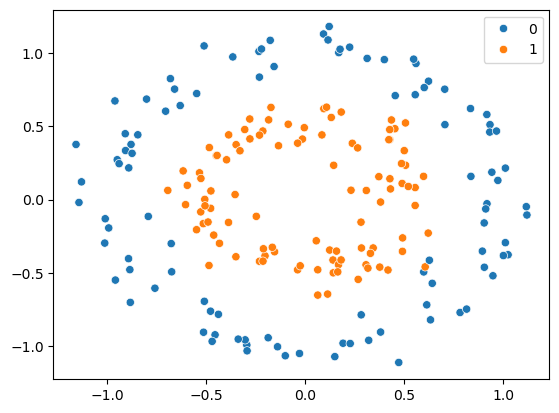

In [28]:
sns.scatterplot(x=X_circles[:,0], y=X_circles[:,1], hue=y_circles)

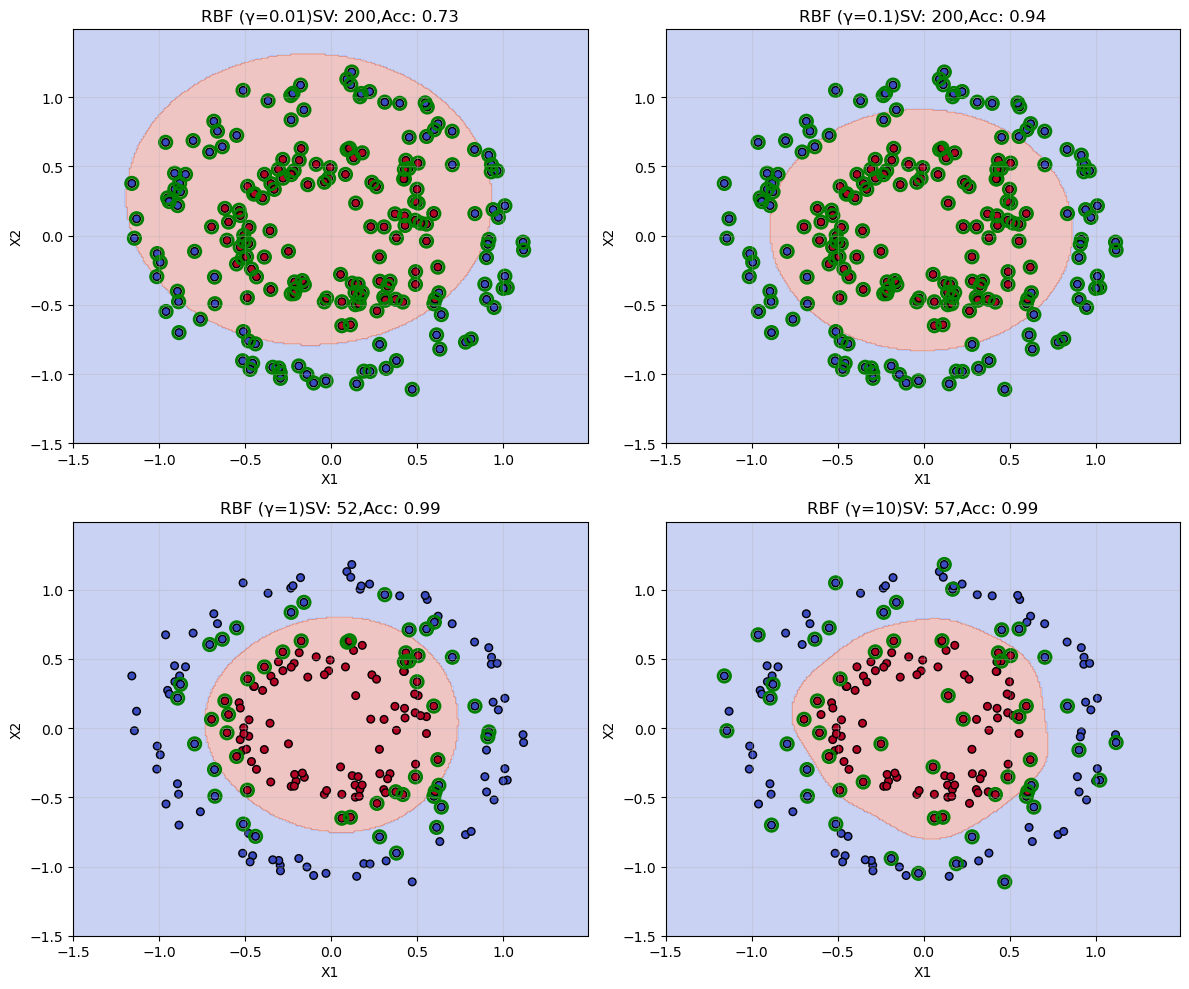

γ 값의 영향:
• γ가 작음 (0.01): 부드러운 경계, 넓은 영향
• γ가 중간 (0.1-1): 적절한 복잡도
• γ가 큼 (10): 복잡한 경계, 과적합 위험


In [32]:
# 다양한 gamma 값으로 RBF Kernel SVM
gamma_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, gamma in enumerate(gamma_values):
    ax = axes[idx // 2, idx % 2]
    # RBF Kernel SVM
    clf_rbf = svm.SVC(kernel='rbf', gamma=gamma, C=1.0)
    clf_rbf.fit(X_circles, y_circles)
    
    # 결정 경계
    h = .01
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    Z = clf_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
        # 시각화
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_circles[:, 0], X_circles[:, 1], 
              c=y_circles, cmap='coolwarm', 
              s=30, edgecolors='black')
    
    # Support Vectors
    ax.scatter(clf_rbf.support_vectors_[:, 0], 
              clf_rbf.support_vectors_[:, 1],
              s=80, facecolors='none', 
              edgecolors='green', linewidths=2)
    
    ax.set_title(f'RBF (γ={gamma})'
                f'SV: {len(clf_rbf.support_)},'
                f'Acc: {clf_rbf.score(X_circles, y_circles):.2f}')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("γ 값의 영향:")
print("• γ가 작음 (0.01): 부드러운 경계, 넓은 영향")
print("• γ가 중간 (0.1-1): 적절한 복잡도")
print("• γ가 큼 (10): 복잡한 경계, 과적합 위험")

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# 데이터 정규화 (중요!)
scaler = StandardScaler()
X_circles_scaled = scaler.fit_transform(X_circles)

# 파라미터 그리드 정의
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf']
}

# Grid Search
grid_search = GridSearchCV(
    svm.SVC(),           # 기본 SVM
    param_grid,          # 파라미터 그리드
    cv=5,               # 5-fold CV
    scoring='accuracy',  # 평가 지표
    n_jobs=-1,          # 병렬 처리
    verbose=1           # 진행상황 출력
)

# 학습
print("Grid Search 시작...")
grid_search.fit(X_circles_scaled, y_circles)

# 최적 파라미터
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 CV 점수: {grid_search.best_score_:.3f}")

# 최적 모델로 예측
best_model = grid_search.best_estimator_
print(f"Support Vectors: {len(best_model.support_)}")

Grid Search 시작...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
최적 파라미터: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
최고 CV 점수: 0.990
Support Vectors: 48


Exception ignored in: <function ResourceTracker.__del__ at 0x102f19bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104e69bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107035bc0>
Traceback (most recent call last

In [36]:
# PPT랑 다름
X_test,y_test = make_circles(50,factor=0.5, noise=0.1, random_state =42)

In [37]:
grid_search.best_estimator_.score(X_test,y_test)

0.5

In [40]:
import pandas as pd
import seaborn as sns

# Grid Search 결과를 DataFrame으로 변환
results_df = pd.DataFrame(grid_search.cv_results_)

# C와 gamma별 평균 점수 피벗 테이블
pivot_table = results_df.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C')

In [41]:
pivot_table

param_C,0.1,1.0,10.0,100.0
param_gamma,,,,
0.01,0.610,0.610,0.715,0.980
0.10,0.925,0.985,0.990,0.990
1.00,0.985,0.990,0.975,0.970
10.00,0.960,0.980,0.985,0.975
100.00,0.805,0.865,0.870,0.870


Exception ignored in: <function ResourceTracker.__del__ at 0x106931bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x112a69bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1057adbc0>
Traceback (most recent call last